# Model Training — Rossmann Sales Forecasting

## What we do in this notebook:
1. Load engineered features
2. Split data — Train / Validation / Test
3. Train baseline model
4. Train LightGBM model
5. Evaluate model performance
6. SHAP feature importance
7. Forecast visualization
8. Save model & reports

## Model Choice — LightGBM
- Handles large datasets fast
- Works well with tabular data
- Built-in feature importance
- Industry standard for forecasting

## Step 1 — Import Libraries

In [3]:
# ── Standard libraries ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# ── Machine Learning ─────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
import lightgbm as lgb

# ── Display settings ─────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style="whitegrid")

# ── Paths ─────────────────────────────────────────────────────────
DATA_PATH    = '../data/processed/train_features.csv'
TEST_PATH = '../data/processed/test.csv'
FIGURES_PATH = '../reports/'

print("✅ Libraries loaded!")
print(f"📁 Figures will be saved to: {FIGURES_PATH}")

✅ Libraries loaded!
📁 Figures will be saved to: ../reports/


## Step 2 — Load Data
Loading the engineered feature dataset from Feature Engineering notebook.

In [4]:
# ── Load feature engineered data ─────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

# ── Quick check ───────────────────────────────────────────────────
print(f"📦 Shape      : {df_raw.shape}")
print(f"📋 Columns    : {df_raw.shape[1]}")
print(f"🎯 Target     : Sales")
print()
print("📋 First 3 rows:")
display(df_raw.head(3))
print()
print("📊 Target variable stats:")
print(f"   Min  : €{df_raw['Sales'].min():,.0f}")
print(f"   Max  : €{df_raw['Sales'].max():,.0f}")
print(f"   Mean : €{df_raw['Sales'].mean():,.0f}")
print(f"   Std  : €{df_raw['Sales'].std():,.0f}")
print()
print("✅ Data loaded successfully!")

📦 Shape      : (985989, 37)
📋 Columns    : 37
🎯 Target     : Sales

📋 First 3 rows:


,Sales,Store,Open,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,Week,DayOfWeek,DayOfYear,Quarter,Season,IsWeekend,IsMonthStart,IsMonthEnd,StateHoliday,SchoolHoliday,Lag_1,Lag_7,Lag_14,Lag_21,Lag_28,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_28,Rolling_Std_7,Rolling_Std_14,Rolling_Std_28
0,3725,1,1,2,0,1270.00,9.00,2008.00,0,0,0.00,0.00,0,2013,1,29,5,1,29,1,0,0,0,0,0,0,4055.00,5720.00,3900.00,5580.00,0.00,4533.14,4170.50,4121.29,2080.02,1899.60,2075.63
1,4601,1,1,2,0,1270.00,9.00,2008.00,0,0,0.00,0.00,0,2013,1,30,5,2,30,1,0,0,0,0,0,0,3725.00,5578.00,4008.00,5471.00,5530.00,4248.14,4158.00,4254.32,2026.27,1902.09,1914.85
2,4709,1,1,2,0,1270.00,9.00,2008.00,0,0,0.00,0.00,0,2013,1,31,5,3,31,1,0,0,0,1,0,0,4601.00,5195.00,4044.00,4892.00,4327.00,4108.57,4200.36,4221.14,1951.68,1905.09,1899.91



📊 Target variable stats:
   Min  : €0
   Max  : €41,551
   Mean : €5,793
   Std  : €3,858

✅ Data loaded successfully!


In [5]:
df_raw[['DayOfWeek','IsWeekend']].drop_duplicates()

,DayOfWeek,IsWeekend
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,0,0


In [6]:
df_raw.groupby('DayOfWeek')['Sales'].agg(['count','mean'])

,count,mean
DayOfWeek,,
0,140270,7833.82
1,141204,7065.87
2,141205,6566.53
3,141385,6254.21
4,141385,6733.10
5,140270,5863.62
6,140270,206.52


## Step 3 — Train / Validation / Test Split
Splitting data based on TIME — not random!

Why time-based split?
→ Random split causes data leakage
→ Future data leaks into training = fake accuracy
→ Time-based split = realistic evaluation

Split strategy:
→ Train      : Jan 2013 — Dec 2014  (2 full years)
→ Validation : Jan 2015 — May 2015  (tune model)
→ Test       : Jun 2015 — Jul 2015  (final evaluation)

In [7]:
# # ── Filter only open stores ───────────────────────────────────────
# # Closed stores have Sales = 0, not useful for forecasting
df = df_raw[df_raw['Open'] == 1].copy()
df.drop(columns=['Open'], inplace=True)

# ── Convert date — already dropped but recreate from Year/Month/Day
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

# ── Define split dates ────────────────────────────────────────────
train_end = '2015-03-31'

# ── Split ─────────────────────────────────────────────────────────
train_df = df[df['Date'] <= train_end].copy()
val_df   = df[(df['Date'] > train_end)].copy()

# ── Define features and target ────────────────────────────────────
drop_cols = ['Sales', 'Date']
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df['Sales']

X_val   = val_df[feature_cols]
y_val   = val_df['Sales']

# ── Verify ────────────────────────────────────────────────────────
print("📊 Dataset Split Summary:")
print("-" * 50)
print(f"   Train      : {train_df['Date'].min().date()} → "
      f"{train_df['Date'].max().date()} | {len(train_df):,} rows")
print(f"   Validation : {val_df['Date'].min().date()} → "
      f"{val_df['Date'].max().date()} | {len(val_df):,} rows")
print()
print(f"   Total features : {len(feature_cols)}")
print(f"   Feature list   : {feature_cols}")
print()
print("✅ Data split complete — no data leakage!")

📊 Dataset Split Summary:
--------------------------------------------------
   Train      : 2013-01-29 → 2015-03-31 | 707,423 rows
   Validation : 2015-04-01 → 2015-07-31 | 111,422 rows

   Total features : 35
   Feature list   : ['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day', 'Week', 'DayOfWeek', 'DayOfYear', 'Quarter', 'Season', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'StateHoliday', 'SchoolHoliday', 'Lag_1', 'Lag_7', 'Lag_14', 'Lag_21', 'Lag_28', 'Rolling_Mean_7', 'Rolling_Mean_14', 'Rolling_Mean_28', 'Rolling_Std_7', 'Rolling_Std_14', 'Rolling_Std_28']

✅ Data split complete — no data leakage!


## Step 4 — Baseline Model
Before LightGBM, we build a simple baseline model.
Baseline = predict mean sales for every day.

Why baseline?
→ Sets minimum performance bar
→ LightGBM must beat this to be useful
→ Professional practice in ML projects

In [6]:
# ── Baseline: predict mean sales from training set ────────────────
baseline_pred = np.full(len(y_val), y_train.mean())

# ── Baseline metrics ──────────────────────────────────────────────
baseline_rmse = np.sqrt(mean_squared_error(y_val, baseline_pred))
baseline_mae  = mean_absolute_error(y_val, baseline_pred)
baseline_mape = np.mean(np.abs((y_val - baseline_pred) / y_val)) * 100
baseline_r2   = r2_score(y_val, baseline_pred)

print("📊 Baseline Model Performance (predict mean always):")
print("-" * 50)
print(f"   RMSE : €{baseline_rmse:,.0f}")
print(f"   MAE  : €{baseline_mae:,.0f}")
print(f"   MAPE : {baseline_mape:.2f}%")
print(f"   R²   : {baseline_r2:.4f}")
print()

📊 Baseline Model Performance (predict mean always):
--------------------------------------------------
   RMSE : €3,170
   MAE  : €2,284
   MAPE : inf%
   R²   : -0.0211



## Step 5 — Model Training
Training a gradient boosting model with early stopping.
Early stopping = stop training when validation score
stops improving — prevents overfitting.

In [7]:
models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),

    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=15,
        max_samples=0.7,
        n_jobs=2,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        random_state=42,
        n_jobs=2
    ),

    "Light GBM": lgb.LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=20,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        random_state=42,
        verbose=-1
    )
}

In [ ]:
results = []

# Train and Evaluate
for name, model in models.items():

    print(f"Training {name}...")

    try:
        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        mae = mean_absolute_error(y_val, preds)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        r2 = r2_score(y_val, preds)

        results.append({
            "Model": name,
            "MAE": round(mae, 2),
            "RMSE": round(rmse, 2),
            "R2": round(r2, 4)
        })

    except Exception as e:
        print(f"{name} failed: {e}")
    # Final comparison table

comparison = (
    pd.DataFrame(results)
      .sort_values("RMSE")
      .reset_index(drop=True)
)

comparison

Training Linear Regression...
Training Ridge Regression...
Training Random Forest...
Training XGBoost...
Training Light GBM...


,Model,MAE,RMSE,R2
0,XGBoost,649.83,924.09,0.91
1,Light GBM,659.80,932.68,0.91
2,Random Forest,670.60,968.03,0.90
3,Linear Regression,976.88,1334.39,0.82
4,Ridge Regression,977.01,1334.88,0.82


### Final Best Model

In [11]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from lightgbm import LGBMRegressor

In [12]:
lgbm = LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

param_grid = {
    'n_estimators': [300, 500, 700, 1000],
    'learning_rate': [0.02, 0.05, 0.08, 0.1],
    'num_leaves': [15, 31, 50, 70],
    'max_depth': [-1, 5, 8, 12],
    'min_child_samples': [10, 20, 30, 50],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=param_grid,
    n_iter=15,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=LGBMRegressor(n_jobs=-1, objective='regression',
                                           random_state=42, verbosity=-1),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1.0],
                                        'learning_rate': [0.02, 0.05, 0.08,
                                                          0.1],
                                        'max_depth': [-1, 5, 8, 12],
                                        'min_child_samples': [10, 20, 30, 50],
                                        'n_estimators': [300, 500, 700, 1000],
                                        'num_leaves': [15, 31, 50, 70],
                                        'subsample': [0.8, 0.9, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [13]:
print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV RMSE:")
print(-random_search.best_score_)

Best parameters:
{'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 1000, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

Best CV RMSE:
761.4790554302872


In [14]:
best_lgbm = random_search.best_estimator_
y_val_pred = best_lgbm.predict(X_val)

mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("Tuned LightGBM Results")
print("----------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

Tuned LightGBM Results
----------------------
MAE  : 647.90
RMSE : 908.04
R²   : 0.92


In [15]:
# # ── LightGBM datasets ─────────────────────────────────────────────
# lgb_train = lgb.Dataset(X_train, label=y_train)
# lgb_val   = lgb.Dataset(X_val,   label=y_val, reference=lgb_train)

# # ── Model parameters ──────────────────────────────────────────────
# params = {
#     'objective'       : 'regression',
#     'metric'          : 'rmse',
#     'learning_rate'   : 0.05,
#     'num_leaves'      : 63,
#     'min_child_samples': 20,
#     'feature_fraction': 0.8,
#     'bagging_fraction': 0.8,
#     'bagging_freq'    : 5,
#     'verbose'         : -1,
#     'random_state'    : 42
# }

# # ── Callbacks ─────────────────────────────────────────────────────
# callbacks = [
#     lgb.early_stopping(stopping_rounds=50, verbose=True),
#     lgb.log_evaluation(period=100)
# ]

# # ── Train model ───────────────────────────────────────────────────
# print("🚀 Training LightGBM model...")
# print("-" * 50)

# model = lgb.train(
#     params,
#     lgb_train,
#     num_boost_round=1000,
#     valid_sets=[lgb_train, lgb_val],
#     valid_names=['train', 'validation'],
#     callbacks=callbacks
# )

# print()
# print(f"✅ Training complete!")
# print(f"🌳 Best iteration : {model.best_iteration}")

## Step 6 — Model Evaluation
Evaluating LightGBM performance on unseen test data
and comparing against baseline model.

In [16]:
X_final = df[feature_cols]
y_final = df['Sales']
final_lgbm = LGBMRegressor(
    objective='regression',
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **random_search.best_params_
)
final_lgbm.fit(X_final, y_final)

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              n_jobs=-1, num_leaves=50, objective='regression', random_state=42,
              verbosity=-1)

In [18]:
# # ── Predict on test set ───────────────────────────────────────────
# y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# # ── Clip negative predictions to 0 (sales can't be negative) ─────
# y_pred = np.clip(y_pred, 0, None)

# # ── Calculate metrics ─────────────────────────────────────────────
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# mae  = mean_absolute_error(y_test, y_pred)
# mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
# r2   = r2_score(y_test, y_pred)

# # ── Comparison table ──────────────────────────────────────────────
# print("📊 Model Performance Comparison:")
# print("=" * 55)
# print(f"{'Metric':<10} {'Baseline':>15} {'LightGBM':>15} {'Improvement':>12}")
# print("-" * 55)
# print(f"{'RMSE':<10} €{baseline_rmse:>13,.0f} €{rmse:>13,.0f} "
#       f"{((baseline_rmse-rmse)/baseline_rmse*100):>11.1f}%")
# print(f"{'MAE':<10} €{baseline_mae:>13,.0f} €{mae:>13,.0f} "
#       f"{((baseline_mae-mae)/baseline_mae*100):>11.1f}%")
# print(f"{'MAPE':<10} {baseline_mape:>14.2f}% {mape:>14.2f}% "
#       f"{((baseline_mape-mape)/baseline_mape*100):>11.1f}%")
# print(f"{'R²':<10} {baseline_r2:>15.4f} {r2:>15.4f} "
#       f"{'—':>12}")
# print("=" * 55)
# print()
# print(f"💡 LightGBM is {((baseline_mape-mape)/baseline_mape*100):.1f}% "
#       f"better than baseline on MAPE!")

## Step 7 — Visualizations & Save Reports
Creating charts to visualize model performance
and saving them to reports/figures/ folder.
### 7.1 — Actual vs Predicted Plot

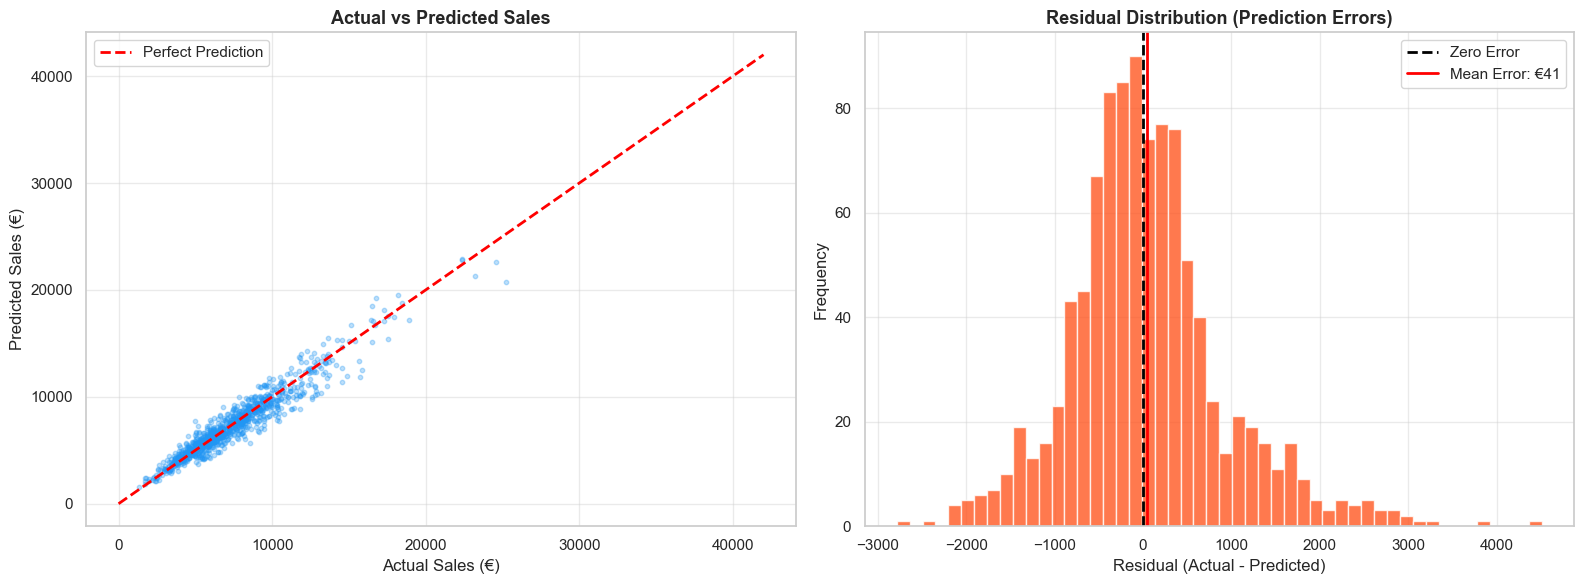

✅ Chart saved → reports/01_actual_vs_predicted.png


In [19]:
# ── Sample 1000 points for plotting (faster rendering) ────────────
sample_idx = np.random.choice(len(y_val), 1000, replace=False)
y_test_sample = np.array(y_val)[sample_idx]
y_pred_sample = y_val_pred[sample_idx]

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot — Actual vs Predicted
axes[0].scatter(y_test_sample, y_pred_sample,
                alpha=0.3, color='#2196F3', s=10)
axes[0].plot([0, 42000], [0, 42000],
             color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted Sales', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Sales (€)')
axes[0].set_ylabel('Predicted Sales (€)')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Residual plot — Error distribution
residuals = y_test_sample - y_pred_sample
axes[1].hist(residuals, bins=50, color='#FF5722',
             edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='black', linewidth=2,
                linestyle='--', label='Zero Error')
axes[1].axvline(x=residuals.mean(), color='red',
                linewidth=2, label=f'Mean Error: €{residuals.mean():,.0f}')
axes[1].set_title('Residual Distribution (Prediction Errors)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────
plt.savefig(f'{FIGURES_PATH}01_actual_vs_predicted.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/01_actual_vs_predicted.png")

### 7.2 — Feature Importance Plot
Which features does LightGBM use most for predictions?
This helps us understand what drives sales forecasting.

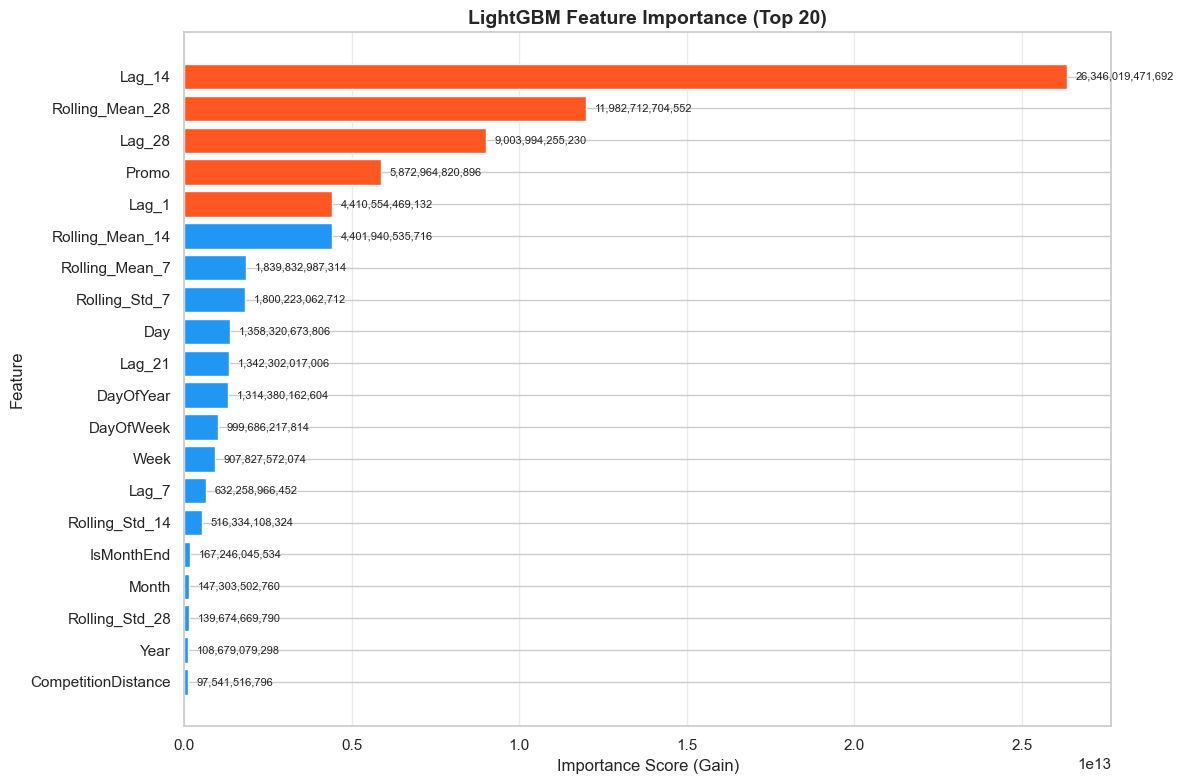

📊 Top 10 Most Important Features:
---------------------------------------------
    1. Lag_14                    : 26,346,019,471,692
    2. Rolling_Mean_28           : 11,982,712,704,552
    3. Lag_28                    : 9,003,994,255,230
    4. Promo                     : 5,872,964,820,896
    5. Lag_1                     : 4,410,554,469,132
    6. Rolling_Mean_14           : 4,401,940,535,716
    7. Rolling_Mean_7            : 1,839,832,987,314
    8. Rolling_Std_7             : 1,800,223,062,712
    9. Day                       : 1,358,320,673,806
   10. Lag_21                    : 1,342,302,017,006


In [21]:
# ── Get feature importance ────────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature': final_lgbm.booster_.feature_name(),
    'Importance': final_lgbm.booster_.feature_importance(
        importance_type='gain'
    )
}).sort_values('Importance', ascending=True)

# ── Top 20 features ───────────────────────────────────────────────
top20 = importance_df.tail(20)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#2196F3' if i < 15 else '#FF5722'
          for i in range(len(top20))]

bars = ax.barh(top20['Feature'], top20['Importance'],
               color=colors, edgecolor='white')

ax.set_title('LightGBM Feature Importance (Top 20)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score (Gain)')
ax.set_ylabel('Feature')
ax.grid(axis='x', alpha=0.4)

# ── Add value labels ──────────────────────────────────────────────
for bar, val in zip(bars, top20['Importance']):
    ax.text(bar.get_width() + max(top20['Importance'])*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────
plt.savefig(f'{FIGURES_PATH}02_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Top 10 features ───────────────────────────────────────────────
print("📊 Top 10 Most Important Features:")
print("-" * 45)
for i, (_, row) in enumerate(importance_df.tail(10).iloc[::-1].iterrows()):
    print(f"   {i+1:>2}. {row['Feature']:<25} : {row['Importance']:,.0f}")

### 7.3 — Save Model & Forecast Visualization
Saving trained model for dashboard use and
visualizing forecast vs actual sales over time.

In [17]:
import joblib

joblib.dump(
    final_lgbm,
    '../src/rossmann_lightgbm.pkl'
)

print(f"✅ Model saved!")
print(f"📁 Location  : src/rossmann_lightgbm.pkl")
print()


✅ Model saved!
📁 Location  : src/rossmann_lightgbm.pkl



## Step 8 — Recursive Future Forecasting
Building a function that predicts future sales
week by week using previous predictions as input.


In [1]:
def forecast_future(history_df, future_df, model, feature_cols):

    history = history_df.copy()
    future = future_df.copy()

    history["Date"] = pd.to_datetime(history["Date"])
    future["Date"] = pd.to_datetime(future["Date"])

    predictions = []

    # Keep only the latest 28 days for each store
    store_history = {
        store: group.sort_values("Date").tail(28).copy()
        for store, group in history.groupby("Store")
    }

    for current_date in sorted(future["Date"].unique()):
        current_date = pd.Timestamp(current_date)
        today = future[future["Date"] == current_date]

        for _, future_row in today.iterrows():

            store = future_row["Store"]
            hist = store_history[store].sort_values("Date")

            # Start with the actual future/base features
            row = future_row.copy()

            # -------------------------
            # Date features
            # -------------------------
            row["Year"] = current_date.year
            row["Month"] = current_date.month
            row["Day"] = current_date.day
            row["Week"] = current_date.isocalendar().week
            row["DayOfWeek"] = current_date.dayofweek + 1
            row["DayOfYear"] = current_date.dayofyear
            row["Quarter"] = (current_date.month - 1) // 3 + 1
            row["IsWeekend"] = int(current_date.dayofweek >= 5)
            row["IsMonthStart"] = int(current_date.is_month_start)
            row["IsMonthEnd"] = int(current_date.is_month_end)
            month = current_date.month

            if month in [12, 1, 2]:
                row["Season"] = 'Winter'
            elif month in [3, 4, 5]:
                row["Season"] = 'Spring'
            elif month in [6, 7, 8]:
                row["Season"] = 'Summer'
            else:
                row["Season"] = 'Autumn'
            # -------------------------
            # Categorical Columns
            # -------------------------
            CAT_MAPPINGS = {
                'Season': {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Autumn': 3},
                'StoreType': {'a': 0, 'b': 1, 'c': 2, 'd': 3},
                'Assortment': {'a': 0, 'b': 1, 'c': 2},
                'StateHoliday': {'0': 0, 'a': 1, 'b': 2, 'c': 3},
                'PromoInterval': {
                    'None': 0,
                    'Jan,Apr,Jul,Oct': 1,
                    'Feb,May,Aug,Nov': 2,
                    'Mar,Jun,Sept,Dec': 3
                }
            }

            for col, mapping in CAT_MAPPINGS.items():
                row[col] = mapping[str(row[col])]

            # -------------------------
            # Historical sales
            # -------------------------
            sales = hist["Sales"].values

            row["Lag_1"] = sales[-1]
            row["Lag_7"] = sales[-7]
            row["Lag_14"] = sales[-14]
            row["Lag_21"] = sales[-21]
            row["Lag_28"] = sales[-28]
            row["Rolling_Mean_7"] = np.mean(sales[-7:])
            row["Rolling_Mean_14"] = np.mean(sales[-14:])
            row["Rolling_Mean_28"] = np.mean(sales[-28:])
            row["Rolling_Std_7"] = np.std(sales[-7:])
            row["Rolling_Std_14"] = np.std(sales[-14:])
            row["Rolling_Std_28"] = np.std(sales[-28:])

            # -------------------------
            # Predict
            # -------------------------
            if row["Open"] == 0:
                pred = 0

            else:
                X = pd.DataFrame([row])[feature_cols]
                if X.isnull().any().any():
                    raise ValueError(
                        f"Missing features for Store {store}, Date {current_date}"
                    )
                pred = model.predict(X)[0]
                pred = max(0, pred)

            row["Sales"] = pred
            # Save prediction
            predictions.append(row)
            # -------------------------
            # Add prediction to history
            # -------------------------
            store_history[store] = (
                pd.concat(
                    [hist, pd.DataFrame([row])],
                    ignore_index=True
                )
                .sort_values("Date")
                .tail(28)
            )

    return pd.DataFrame(predictions)

## Step 9 — Test Recursive Forecasting
Testing our forecast function on Store 1 for 8 weeks ahead.

In [8]:
# ── Load feature data for testing forecast function ───────────────
df_features = pd.read_csv('../data/processed/train_features.csv')
df_features['Date'] = pd.to_datetime(df_features[['Year','Month','Day']])

print(f"✅ df_features loaded : {df_features.shape}")
print(f"📅 Date range : {df_features['Date'].min().date()} → {df_features['Date'].max().date()}")

✅ df_features loaded : (985989, 38)
📅 Date range : 2013-01-29 → 2015-07-31


In [9]:
# ── Load feature data for testing forecast function ───────────────
test = pd.read_csv('../data/processed/test.csv',
                           low_memory=False)
test['Date'] = pd.to_datetime(test['Date'])

test = test.sort_values(['Store','Date']).reset_index(drop=True)

print(f"✅ Test data loaded : {test.shape}")
print(f"📅 Date range : {test['Date'].min().date()} → {test['Date'].max().date()}")

✅ Test data loaded : (46830, 18)
📅 Date range : 2015-06-20 → 2015-07-31


In [10]:
import joblib
model = joblib.load('../src/rossmann_lightgbm.pkl')

In [ ]:
y_test = test['Sales']
X_test = test.drop(columns=['Sales'])

pred = forecast_future(df_features, X_test, model, feature_cols)
pred = pred.sort_values(['Store','Date']).reset_index(drop=True)
y_pred = pred['Sales']

# # ── Calculate metrics ─────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2   = r2_score(y_test, y_pred)

print("Forecast Test Results")
print("----------------------")
print(f"MAE  : {mae:.2f}")
print(f"MAPE : {mape:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.2f}")

Forecast Test Results
----------------------
MAE  : 506.77
MAPE : 8.76
RMSE : 801.47
R²   : 0.95


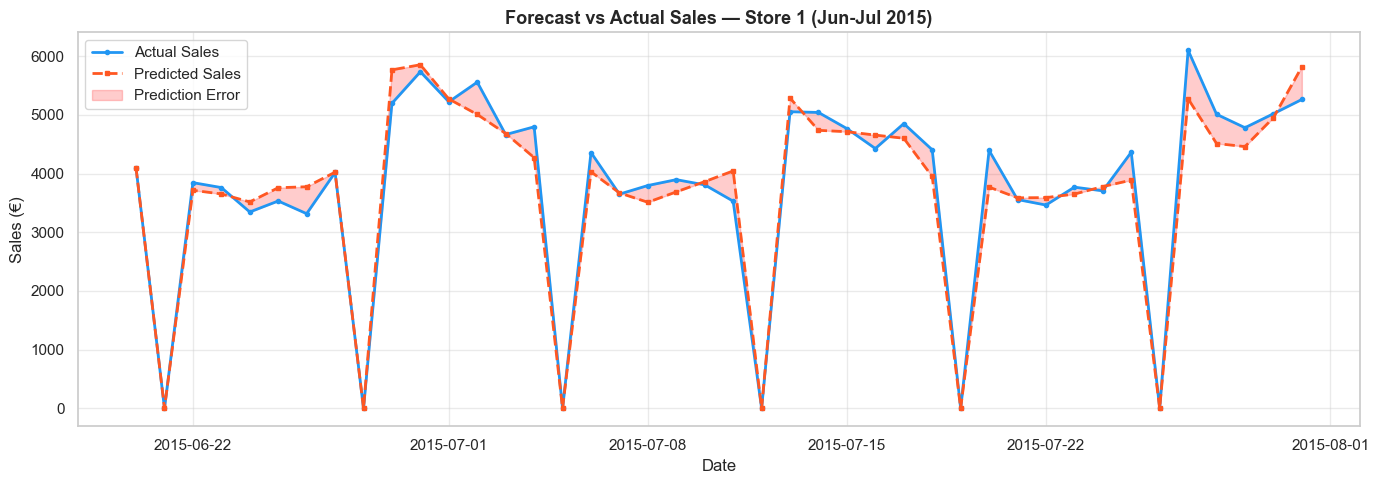

✅ Chart saved → reports/03_forecast_vs_actual.png


In [58]:
# ── Forecast vs Actual — Single Store ────────────────────────────
# Pick Store 1 from test set for clean visualization
pred = pred.rename(columns={'Sales':'Predicted_Sales'})
test = test.merge(pred[['Store','Date','Predicted_Sales']],
                  on=['Store','Date'], how='left')
store1_test = test[test['Store'] == 1].copy()

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(store1_test['Date'], store1_test['Sales'],
        color='#2196F3', linewidth=2,
        label='Actual Sales', marker='o', markersize=3)
ax.plot(store1_test['Date'], store1_test['Predicted_Sales'],
        color='#FF5722', linewidth=2,
        label='Predicted Sales', linestyle='--',
        marker='s', markersize=3)

# ── Fill between for error visualization ─────────────────────────
ax.fill_between(store1_test['Date'],
                store1_test['Sales'], store1_test['Predicted_Sales'],
                alpha=0.2, color='red', label='Prediction Error')

ax.set_title('Forecast vs Actual Sales — Store 1 (Jun-Jul 2015)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (€)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────
plt.savefig(f'{FIGURES_PATH}03_forecast_vs_actual.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/03_forecast_vs_actual.png")

### Future Forecast

In [17]:
# ── Load feature data for testing forecast function ───────────────
future = pd.read_csv('../data/processed/kaggle_test.csv')
future['Date'] = pd.to_datetime(future['Date'])
print(future['Date'].min(), future['Date'].max())
store = pd.read_csv('../data/processed/store.csv')

def forecast(history_df, test_df, store_df, model, feature_cols):

    future_df = test_df.merge(store_df, on='Store', how='inner')

    return forecast_future(history_df, future_df, model, feature_cols)

2015-08-01 00:00:00 2015-09-17 00:00:00


In [22]:
# ── Test forecast for Store 1 — 6 weeks ahead ─────────────────────
store_id    = 1

print(f"🔮 Forecasting Store {store_id} — 6 weeks ahead...")
print("-" * 50)
future_1 = future[future['Store'] == store_id].sort_values('Date').copy()
df_features_1 = df_features[df_features['Store'] == store_id].sort_values('Date').copy()

future_df = forecast(
    df_features_1, future_1, store, model, feature_cols)

future_df['Date'] = pd.to_datetime(future_df[['Year', 'Month', 'Day']])
# ── Create forecast dataframe ─────────────────────────────────────
forecast_df = future_df[['Date' ,'Sales']]

print(f"✅ Forecast generated!")

🔮 Forecasting Store 1 — 6 weeks ahead...
--------------------------------------------------
✅ Forecast generated!


## Step 10 — Visualize Future Forecast
Plotting historical sales + future predictions together.

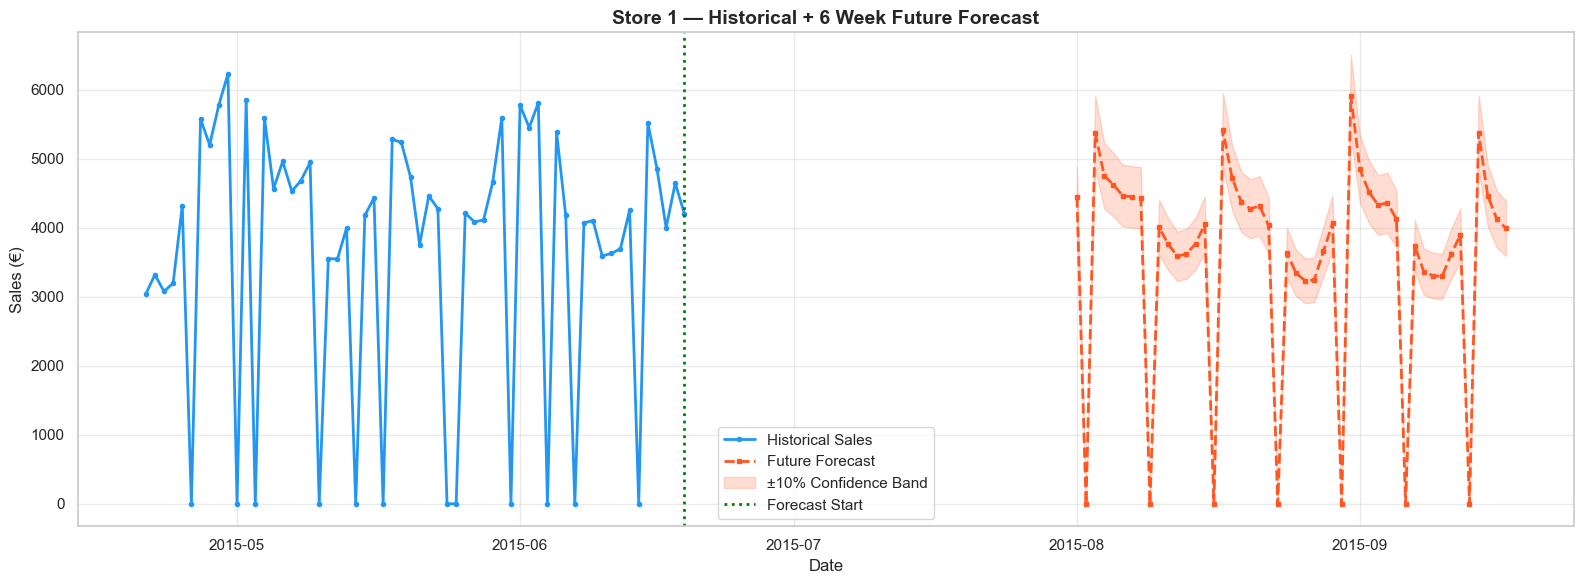

✅ Future forecast chart saved!
✅ Store 1 forecast: Aug-Sep 2015


In [24]:
# ── Get last 60 days of actual sales for Store 1 ──────────────────
historical = df_features[
    df_features['Store'] == store_id
].tail(60)[['Date', 'Sales']].copy()

# ── Plot historical + future ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

# Historical actual sales
ax.plot(historical['Date'], historical['Sales'],
        color='#2196F3', linewidth=2,
        label='Historical Sales', marker='o', markersize=3)

# Future predictions
ax.plot(forecast_df['Date'], forecast_df['Sales'],
        color='#FF5722', linewidth=2,
        linestyle='--', label='Future Forecast',
        marker='s', markersize=3)

# Confidence band (±10% uncertainty)
ax.fill_between(forecast_df['Date'],
                forecast_df['Sales'] * 0.90,
                forecast_df['Sales'] * 1.10,
                alpha=0.2, color='#FF5722',
                label='±10% Confidence Band')

# Vertical line separating history and future
ax.axvline(x=historical['Date'].max(),
           color='green', linewidth=2,
           linestyle=':', label='Forecast Start')

ax.set_title(f'Store {store_id} — Historical + 6 Week Future Forecast',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (€)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────
plt.savefig(f'{FIGURES_PATH}04_future_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Future forecast chart saved!")
print(f"✅ Store {store_id} forecast: Aug-Sep 2015")